<a href="https://colab.research.google.com/github/meghana507/CODSOFT/blob/main/Task-4/Spam_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Batch 40/81 processed...
Batch 60/81 processed...
Batch 80/81 processed...

Success! Total time: 0.22 minutes.
Feature matrix X shape: (5169, 768)
Final Model Accuracy: 98.74%
              precision    recall  f1-score   support

 Ham (Clean)       0.99      0.99      0.99       889
        Spam       0.95      0.96      0.96       145

    accuracy                           0.99      1034
   macro avg       0.97      0.98      0.97      1034
weighted avg       0.99      0.99      0.99      1034



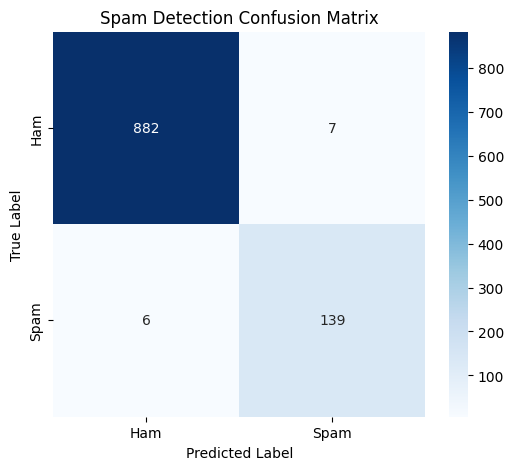

In [3]:
import pandas as pd
import math

df  = pd.read_csv("/content/spam.csv",encoding='latin-1')
df

df=df.drop(columns = ['Unnamed: 2','Unnamed: 3','Unnamed: 4'])

df

df.columns = ['label', 'message']#rename

df = df.drop_duplicates(keep='first')#drop duplicates repeated same message

df.shape

df.loc[:, 'label'] = df['label'].map({'ham': 0, 'spam': 1})

df
df['label'] = df['label'].astype(int)


import torch
import numpy as np
from transformers import AutoModel, AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
model = AutoModel.from_pretrained("distilbert-base-uncased")

model.eval() #turns off drop

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(f"Model loaded on: {device}")

import numpy as np
import time

def get_embeddings(text_list, batch_size=64):
    all_embeddings = []

    total_batches = math.ceil(len(text_list) / batch_size)

    print(f"Starting extraction on {device}. Total batches : {total_batches}")

    for i in range(0, len(text_list), batch_size):
        batch = text_list[i : i + batch_size].tolist()

        # 1. Tokenize
        inputs = tokenizer(batch, padding=True, truncation=True,
                           max_length=128, return_tensors="pt")
        inputs = {key: val.to(device) for key, val in inputs.items()}


        # 2. Get BERT outputs
        with torch.no_grad():
            outputs = model(**inputs)

        # 3. Pull out the [CLS] vector (the summary of the sentence)
        embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        all_embeddings.append(embeddings)

        # Progress update every 20 batches
        if (i // batch_size) % 20 == 0:
            print(f"Batch {i // batch_size}/{total_batches} processed...")

    return np.vstack(all_embeddings)

# Start the timer
start = time.time()

# Process the messages
X = get_embeddings(df['message'])

# Convert labels to numbers (1 for spam, 0 for ham)
y = df['label'].values

end = time.time()
print(f"\nSuccess! Total time: {(end - start)/60:.2f} minutes.")
print(f"Feature matrix X shape: {X.shape}")

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_svm = SVC(kernel='linear', probability=True)
model_svm.fit(X_train, y_train)

y_pred = model_svm.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Final Model Accuracy: {accuracy:.2%}")
print(classification_report(y_test, y_pred, target_names=['Ham (Clean)', 'Spam']))

# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Spam Detection Confusion Matrix')
plt.show()

In [4]:
print(df['label'].unique())
print(df['label'].dtype)

[0 1]
int64
